# Sales Project

## Call Libs

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from matplotlib import pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = None
pd.options.display.max_columns = None

In [ ]:
df = pd.read_csv('/content/all_data.csv', encoding= 'iso-8859-1')

df.head()

,CustomerID,FirstName,LastName,City,Country,Phone,OrderID,OrderDate,OrderNumber,TotalAmount,ProductID,ProductName,UnitPrice,Package,IsDiscontinued,SupplierID,CompanyName,ContactName,City.1,Country.1,Phone.1,Fax
0,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,"542,378.00",440.00,11.00,Queso Cabrales,21.00,1 kg pkg.,False,5.00,Cooperativa de Quesos 'Las Cabras',Antonio del Valle Saavedra,Oviedo,Spain,(98) 598 76 54,NaN
1,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,"542,378.00",440.00,42.00,Singaporean Hokkien Fried Mee,14.00,32 - 1 kg pkgs.,True,20.00,Leka Trading,Chandra Leka,Singapore,Singapore,555-8787,NaN
2,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,"542,378.00",440.00,72.00,Mozzarella di Giovanni,34.80,24 - 200 g pkgs.,False,14.00,Formaggi Fortini s.r.l.,Elio Rossi,Ravenna,Italy,(0544) 60323,(0544) 60603
3,79.00,Karin,Josephs,Münster,Germany,0251-031259,2.00,7/5/2012 0:00,"542,379.00","1,863.40",14.00,Tofu,23.25,40 - 100 g pkgs.,False,6.00,Mayumi's,Mayumi Ohno,Osaka,Japan,(06) 431-7877,NaN
4,79.00,Karin,Josephs,Münster,Germany,0251-031259,2.00,7/5/2012 0:00,"542,379.00","1,863.40",51.00,Manjimup Dried Apples,53.00,50 - 300 g pkgs.,False,24.00,"G'day, Mate",Wendy Mackenzie,Sydney,Australia,(02) 555-5914,(02) 555-4873


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2161 entries, 0 to 2160
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      2158 non-null   float64
 1   FirstName       2158 non-null   object 
 2   LastName        2158 non-null   object 
 3   City            2158 non-null   object 
 4   Country         2158 non-null   object 
 5   Phone           2158 non-null   object 
 6   OrderID         2155 non-null   float64
 7   OrderDate       2155 non-null   object 
 8   OrderNumber     2155 non-null   float64
 9   TotalAmount     2155 non-null   float64
 10  ProductID       2157 non-null   float64
 11  ProductName     2157 non-null   object 
 12  UnitPrice       2157 non-null   float64
 13  Package         2157 non-null   object 
 14  IsDiscontinued  2157 non-null   object 
 15  SupplierID      2157 non-null   float64
 16  CompanyName     2157 non-null   object 
 17  ContactName     2157 non-null   o

## Data Preprocessing

### 1. Delete orders with NaN values based on OrderID

In [ ]:
df.dropna(subset=['OrderID'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 0 to 2154
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      2155 non-null   float64
 1   FirstName       2155 non-null   object 
 2   LastName        2155 non-null   object 
 3   City            2155 non-null   object 
 4   Country         2155 non-null   object 
 5   Phone           2155 non-null   object 
 6   OrderID         2155 non-null   float64
 7   OrderDate       2155 non-null   object 
 8   OrderNumber     2155 non-null   float64
 9   TotalAmount     2155 non-null   float64
 10  ProductID       2155 non-null   float64
 11  ProductName     2155 non-null   object 
 12  UnitPrice       2155 non-null   float64
 13  Package         2155 non-null   object 
 14  IsDiscontinued  2155 non-null   object 
 15  SupplierID      2155 non-null   float64
 16  CompanyName     2155 non-null   object 
 17  ContactName     2155 non-null   object

### 2. Rename City.1, Country.1, Phone.1 Columns, to be CompanyCity, CompanyCountry, CompanyPhone

In [ ]:
df.rename(columns={'City.1': 'CompanyCity', 'Country.1': 'CompanyCountry', 'Phone.1': 'CompanyPhone'}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 0 to 2154
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      2155 non-null   float64
 1   FirstName       2155 non-null   object 
 2   LastName        2155 non-null   object 
 3   City            2155 non-null   object 
 4   Country         2155 non-null   object 
 5   Phone           2155 non-null   object 
 6   OrderID         2155 non-null   float64
 7   OrderDate       2155 non-null   object 
 8   OrderNumber     2155 non-null   float64
 9   TotalAmount     2155 non-null   float64
 10  ProductID       2155 non-null   float64
 11  ProductName     2155 non-null   object 
 12  UnitPrice       2155 non-null   float64
 13  Package         2155 non-null   object 
 14  IsDiscontinued  2155 non-null   object 
 15  SupplierID      2155 non-null   float64
 16  CompanyName     2155 non-null   object 
 17  ContactName     2155 non-null   object

### 3. Change OrderDate Type into Date

In [ ]:
df['OrderDate'] = pd.to_datetime(df.OrderDate)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 0 to 2154
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      2155 non-null   float64       
 1   FirstName       2155 non-null   object        
 2   LastName        2155 non-null   object        
 3   City            2155 non-null   object        
 4   Country         2155 non-null   object        
 5   Phone           2155 non-null   object        
 6   OrderID         2155 non-null   float64       
 7   OrderDate       2155 non-null   datetime64[ns]
 8   OrderNumber     2155 non-null   float64       
 9   TotalAmount     2155 non-null   float64       
 10  ProductID       2155 non-null   float64       
 11  ProductName     2155 non-null   object        
 12  UnitPrice       2155 non-null   float64       
 13  Package         2155 non-null   object        
 14  IsDiscontinued  2155 non-null   object        
 15  SupplierI

### 4. Change ID Columns, and OrderNumber column to integer

In [ ]:
df['CustomerID'] = df.CustomerID.astype(int)
df['OrderID'] = df.OrderID.astype(int)
df['OrderNumber'] = df.OrderNumber.astype(int)
df['ProductID'] = df.ProductID.astype(int)
df['SupplierID'] = df.SupplierID.astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 0 to 2154
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      2155 non-null   int64         
 1   FirstName       2155 non-null   object        
 2   LastName        2155 non-null   object        
 3   City            2155 non-null   object        
 4   Country         2155 non-null   object        
 5   Phone           2155 non-null   object        
 6   OrderID         2155 non-null   int64         
 7   OrderDate       2155 non-null   datetime64[ns]
 8   OrderNumber     2155 non-null   int64         
 9   TotalAmount     2155 non-null   float64       
 10  ProductID       2155 non-null   int64         
 11  ProductName     2155 non-null   object        
 12  UnitPrice       2155 non-null   float64       
 13  Package         2155 non-null   object        
 14  IsDiscontinued  2155 non-null   object        
 15  SupplierI

### 5. Drop dupliacted rows based on OrderID, and OrderNumber

In [ ]:
df.drop_duplicates(subset=['OrderID', 'OrderNumber'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 830 entries, 0 to 2130
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      830 non-null    int64         
 1   FirstName       830 non-null    object        
 2   LastName        830 non-null    object        
 3   City            830 non-null    object        
 4   Country         830 non-null    object        
 5   Phone           830 non-null    object        
 6   OrderID         830 non-null    int64         
 7   OrderDate       830 non-null    datetime64[ns]
 8   OrderNumber     830 non-null    int64         
 9   TotalAmount     830 non-null    float64       
 10  ProductID       830 non-null    int64         
 11  ProductName     830 non-null    object        
 12  UnitPrice       830 non-null    float64       
 13  Package         830 non-null    object        
 14  IsDiscontinued  830 non-null    object        
 15  SupplierID

### 6. Strip and lowercase columns names

In [ ]:
df.columns = df.columns.str.strip().str.lower()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 830 entries, 0 to 2130
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      830 non-null    int64         
 1   firstname       830 non-null    object        
 2   lastname        830 non-null    object        
 3   city            830 non-null    object        
 4   country         830 non-null    object        
 5   phone           830 non-null    object        
 6   orderid         830 non-null    int64         
 7   orderdate       830 non-null    datetime64[ns]
 8   ordernumber     830 non-null    int64         
 9   totalamount     830 non-null    float64       
 10  productid       830 non-null    int64         
 11  productname     830 non-null    object        
 12  unitprice       830 non-null    float64       
 13  package         830 non-null    object        
 14  isdiscontinued  830 non-null    object        
 15  supplierid

### 7. Select only these columns: 'customerid', 'firstname', 'lastname', 'city', 'country', 'orderid', 'ordernumber', 'orderdate', 'totalamount'

In [ ]:
orders = df[['customerid', 'firstname', 'lastname',
        'city', 'country',
        'orderid', 'ordernumber', 'orderdate',
        'totalamount']]

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 830 entries, 0 to 2130
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customerid   830 non-null    int64         
 1   firstname    830 non-null    object        
 2   lastname     830 non-null    object        
 3   city         830 non-null    object        
 4   country      830 non-null    object        
 5   orderid      830 non-null    int64         
 6   ordernumber  830 non-null    int64         
 7   orderdate    830 non-null    datetime64[ns]
 8   totalamount  830 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 64.8+ KB


## Data Analysis

### Univariate Analysis : make analysis for each column
- Describe TotalAmount Column and using Histogram chart to show the data distribution for this column, also show a vertical line for mean and median value
- Describe City By using Bar Chart
- Describe country By using Bar Chart or Pie Chart

#### TotalAmount

In [ ]:
orders['totalamount'].describe()

,totalamount
count,830.00
mean,"1,631.88"
std,"1,990.61"
min,12.50
25%,480.00
50%,"1,015.90"
75%,"2,028.65"
max,"17,250.00"


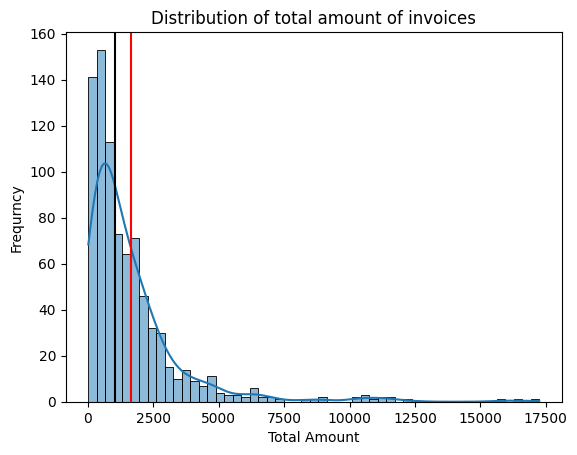

In [ ]:
sns.histplot(data = orders, x= 'totalamount', kde= True)
plt.title('Distribution of total amount of invoices')
plt.xlabel('Total Amount')
plt.ylabel('Frequrncy')
plt.axvline(orders['totalamount'].mean(), color= 'red')
plt.axvline(orders['totalamount'].median(), color= 'black')

#### City

In [ ]:
orders['city'].value_counts()

,count
city,
London,46
Rio de Janeiro,34
Sao Paulo,31
Boise,31
Graz,30
Cunewalde,28
México D.F.,28
Br?cke,19
Cork,19


In [ ]:
px.bar(data_frame= orders['city'].value_counts(), title= 'Distribution of cities')

#### Country

In [ ]:
orders['country'].value_counts()

,count
country,
Germany,122
USA,122
Brazil,83
France,77
UK,56
Venezuela,46
Austria,40
Sweden,37
Canada,30


In [ ]:
px.bar(data_frame= orders['country'].value_counts(), title= 'Distribution of cities')

### Bivariate Analysis : make analysis for each two column
- Total Amount per Country using Bar Chart
- Total Amount per City using Bar Chart
- Total Amount per Orderdate using line chart
- Total Amount per Customer full name using bar chart (top ten customers)

#### Country

In [ ]:
df_amount_country = orders.groupby('country', as_index= False)['totalamount'].sum().sort_values('totalamount', ascending= False)
df_amount_country

,country,totalamount
19,USA,"263,566.98"
8,Germany,"244,640.63"
1,Austria,"139,496.63"
3,Brazil,"114,968.48"
7,France,"85,498.76"
20,Venezuela,"60,814.89"
18,UK,"60,616.51"
16,Sweden,"59,523.70"
9,Ireland,"57,317.39"
4,Canada,"55,334.10"


In [ ]:
px.bar(data_frame = df_amount_country, x= df_amount_country['country'], y= df_amount_country['totalamount'], title= 'Total Amount per Country')

#### City

In [ ]:
df_amount_city = orders.groupby('city', as_index= False)['totalamount'].sum().sort_values('totalamount', ascending= False)
df_amount_city

,city,totalamount
20,Cunewalde,"117,483.39"
9,Boise,"115,673.39"
25,Graz,"113,236.68"
18,Cork,"57,317.39"
35,London,"54,470.21"
52,Rio de Janeiro,"53,999.18"
2,Albuquerque,"52,245.90"
56,Sao Paulo,"45,786.37"
10,Br?cke,"32,555.55"
41,Montréal,"32,203.90"


In [ ]:
px.bar(data_frame = df_amount_city, x= df_amount_city['city'], y= df_amount_city['totalamount'], title= 'Total Amount per City')

#### OrderDate

In [ ]:
date_total = orders[['orderdate', 'totalamount']]
date_total = date_total.set_index('orderdate')
date_total

,totalamount
orderdate,
2012-07-04,440.00
2012-07-05,"1,863.40"
2012-07-08,"1,813.00"
2012-07-08,670.80
2012-07-09,"3,730.00"
2012-07-10,"1,444.80"
2012-07-11,625.20
2012-07-12,"2,490.50"
2012-07-15,517.80


In [ ]:
px.line(data_frame= date_total)

#### Customer

In [ ]:
cust_orders = {
    'fullname' : orders.firstname + ' ' + orders.lastname,
    'totalamount' : orders.totalamount
}

cust_orders = pd.DataFrame(cust_orders)
cust_orders

,fullname,totalamount
0,Paul Henriot,440.00
3,Karin Josephs,"1,863.40"
5,Mario Pontes,"1,813.00"
8,Mary Saveley,670.80
11,Pascale Cartrain,"3,730.00"
14,Mario Pontes,"1,444.80"
17,Yang Wang,625.20
20,Michael Holz,"2,490.50"
24,Paula Parente,517.80
26,Carlos Hern?ndez,"1,119.90"


In [ ]:
fig = px.bar(cust_orders.groupby('fullname')['totalamount'].sum().sort_values(ascending= False).head(10), text_auto= True,
             title= 'Sum of total amount per coustomer', labels= {'fullname' : 'Full Name', 'value' : 'Frequency'})

# Custumize aspect
fig.update_traces(marker_color= 'rgb(158, 202, 341)', marker_line_color= 'rgb(8, 245, 107)', marker_line_width= 2.5,
                  opacity= 0.6, textposition= 'outside')

### Multivariate Analysis : make analysis for multi columns
- Number of countries and totalamount per month orderdate (prefer to put orderdate in index) using bar chart
- total amount of each country per month using scatter chart

#### Number of Countries and TotalAmount per Month

In [ ]:
multivar = orders[['orderdate', 'country', 'totalamount']]
multivar = multivar.set_index('orderdate')
multivar.head()

,country,totalamount
orderdate,,
2012-07-04,France,440.00
2012-07-05,Germany,"1,863.40"
2012-07-08,Brazil,"1,813.00"
2012-07-08,France,670.80
2012-07-09,Belgium,"3,730.00"


In [ ]:
multivar = multivar.resample('M').agg({'country' : 'nunique', 'totalamount' : 'sum'})
multivar

/tmp/ipykernel_12932/1461987687.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,country,totalamount
orderdate,,
2012-07-31,11,"30,192.10"
2012-08-31,11,"26,609.40"
2012-09-30,11,"27,636.00"
2012-10-31,13,"41,203.60"
2012-11-30,11,"49,704.00"
2012-12-31,15,"50,953.40"
2013-01-31,15,"66,692.80"
2013-02-28,14,"41,207.20"
2013-03-31,12,"39,979.90"


In [ ]:
fig = px.bar(data_frame= multivar, x= multivar.index, y= round(multivar.totalamount, 0), color= multivar.country, text_auto= True,
             title= 'Grand total amount of all countries per month', labels= {'orderdate': 'Order Date', 'y' : 'Total Amount'})
fig.update_traces(textposition= 'outside')
fig.update_layout(title_x = 0.5)
fig.show()

#### TotalAmount of each Country per Month

In [ ]:
multivar = orders[['orderdate', 'country', 'totalamount']]
multivar.head()

,orderdate,country,totalamount
0,2012-07-04,France,440.00
3,2012-07-05,Germany,"1,863.40"
5,2012-07-08,Brazil,"1,813.00"
8,2012-07-08,France,670.80
11,2012-07-09,Belgium,"3,730.00"


In [ ]:
multivar.orderdate = multivar.orderdate.dt.to_period('M')

/tmp/ipykernel_12932/1183903935.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
multivar = multivar.groupby(['orderdate' , 'country'],
                            as_index= False)['totalamount'].sum().sort_values(by= 'totalamount', ascending= False)
multivar.head()

,orderdate,country,totalamount
311,2014-04,USA,"34,221.48"
255,2014-01,USA,"27,594.45"
166,2013-07,USA,"26,022.30"
263,2014-02,Germany,"24,760.46"
300,2014-04,Germany,"22,584.49"


In [ ]:
multivar.orderdate = multivar.orderdate.astype('datetime64[ns]')

In [ ]:
px.scatter(data_frame= multivar, x= multivar.orderdate, y= 'totalamount', color= 'country', size= 'totalamount')